<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-07-25 22:54:55--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  78.0MB/s    in 2.6s    

2025-07-25 22:54:59 (78.0 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 173.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 198.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 125.9 MB/s eta 0:00:00


In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [ ]:
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

In [4]:
# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')

In [5]:
Querry = "Select * from main"
df = pd.read_sql_query(Querry, conn)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,None,None,None,None,None,None,None,None,None,United States of America,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,I have never visited Stack Overflow or the Sta...,None,None,None,None,None,Yes,Very favorable,Increase productivity,None,None,None,None,None,None,None,None,None,None,None,None,None,No,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",None,None,None,None,None,United Kingdom of Great Britain and Northern I...,None,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,None,None,None,None,None,None,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,None,None,None,Microsoft Teams;Slack,Slack,Slack,None,None,None,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",None,None,None,None,None,None,None,None,Non

In [6]:
df.shape

(65437, 114)

In [8]:
for i in range(0,114):
    col = df.columns[i]
    null_count = df[col].isnull().sum()
    print(f"{col} : {null_count}")

ResponseId : 0
MainBranch : 0
Age : 0
Employment : 0
RemoteWork : 10631
Check : 0
CodingActivities : 10971
EdLevel : 4653
LearnCode : 4949
LearnCodeOnline : 16200
TechDoc : 24540
YearsCode : 5568
YearsCodePro : 13827
DevType : 5992
OrgSize : 17957
PurchaseInfluence : 18031
BuyNewTool : 20256
BuildvsBuy : 22079
TechEndorse : 21769
Country : 6507
Currency : 18753
CompTotal : 31697
LanguageHaveWorkedWith : 5692
LanguageWantToWorkWith : 9685
LanguageAdmired : 14565
DatabaseHaveWorkedWith : 15183
DatabaseWantToWorkWith : 22879
DatabaseAdmired : 26880
PlatformHaveWorkedWith : 23071
PlatformWantToWorkWith : 30905
PlatformAdmired : 34060
WebframeHaveWorkedWith : 20276
WebframeWantToWorkWith : 26902
WebframeAdmired : 30494
EmbeddedHaveWorkedWith : 43223
EmbeddedWantToWorkWith : 47837
EmbeddedAdmired : 48704
MiscTechHaveWorkedWith : 25994
MiscTechWantToWorkWith : 32473
MiscTechAdmired : 35841
ToolsTechHaveWorkedWith : 12955
ToolsTechWantToWorkWith : 19353
ToolsTechAdmired : 21440
NEWCollabToolsH

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [11]:
df['CompTotal'].sample(10)

13070          NaN
65134          NaN
59634     267504.0
44797      75000.0
14078          NaN
43017    2340000.0
11083          NaN
58630     400000.0
39564          NaN
20222      75000.0
Name: CompTotal, dtype: float64

In [6]:
df['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

In [14]:
# Lấy 10 dòng có CompTotal lớn nhất, bao gồm cột CompTotal và Currency
top_10 = df[['CompTotal', 'Currency','DevType']].nlargest(50, 'CompTotal')

# In kết quả
print(top_10)


           CompTotal                           Currency                                        DevType
14354  1.000000e+150                  EUR European Euro                          Developer, full-stack
34278   1.000000e+65                 RUB\tRussian ruble                        Other (please specify):
17374   1.000000e+53                BRL\tBrazilian real                              DevOps specialist
8814    1.000000e+44    AED United Arab Emirates dirham                            Developer, back-end
20037   8.000000e+27  ANG Netherlands Antillean guilder                                       Designer
24677   1.000000e+20                  EUR European Euro                          Developer, QA or test
27268   1.111111e+15    AED United Arab Emirates dirham                              DevOps specialist
52485   3.040302e+14                  CLP\tChilean peso                          Developer, full-stack
46992   7.587459e+13                  INR\tIndian rupee                  

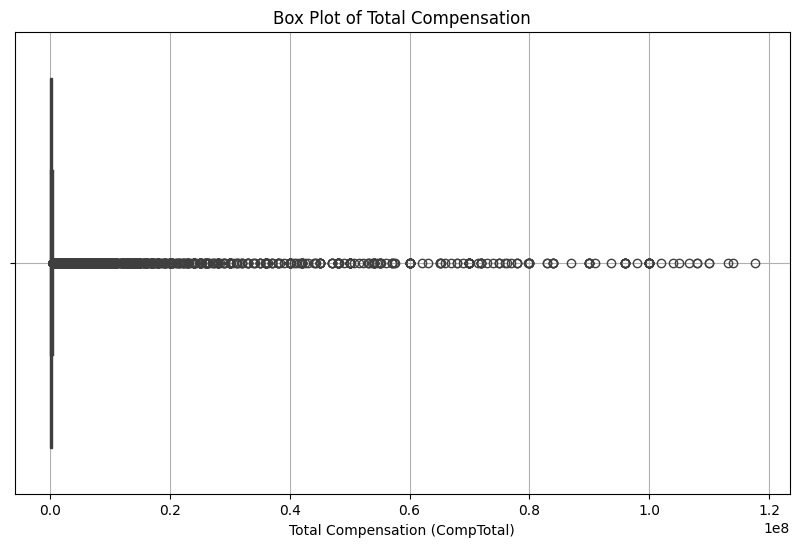

In [9]:
# your code goes here
#Make sure CompTotal is numeric, any non-number values replaced by Null
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

#Drop missing values, including those nulls just created
boxplot_data = df[['CompTotal']].dropna()

# Remove extreme outliers (top 1%)
q99 = boxplot_data["CompTotal"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["CompTotal"] < q99]

# Apply log transformation
boxplot_data.loc[:, "LogCompTotal"] = np.log1p(boxplot_data["CompTotal"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=boxplot_data, x='CompTotal')
plt.title('Box Plot of Total Compensation')
plt.xlabel('Total Compensation (CompTotal)')
plt.grid(True)
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [10]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

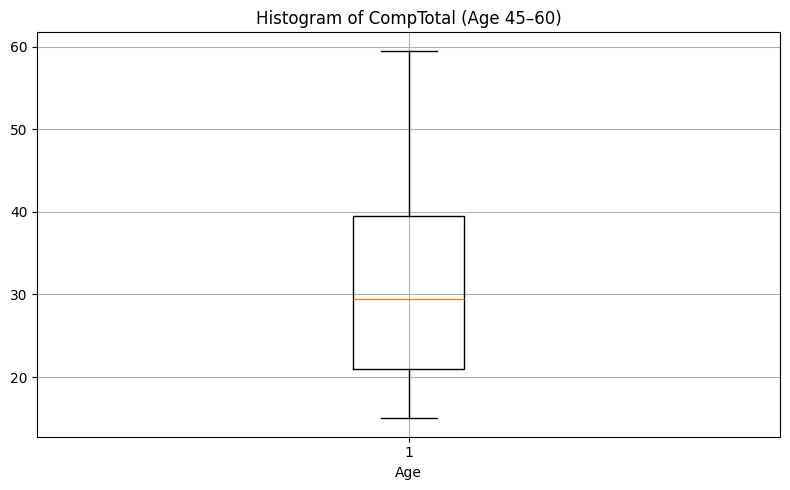

In [19]:
# your code goes here
# Map categorical age to numeric
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['Age_Numeric'] = pd.to_numeric(df['Age'].map(age_mapping))


df_filtered = df[['Age_Numeric']].dropna()

# Remove top 1% outliers
q99 = df_filtered["Age_Numeric"].quantile(0.99)
df_filtered = df_filtered[df_filtered["Age_Numeric"] < q99]

plt.figure(figsize=(8, 5))
plt.boxplot(df_filtered['Age_Numeric'])
plt.xlabel('Age')
plt.title('Histogram of CompTotal (Age 45–60)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


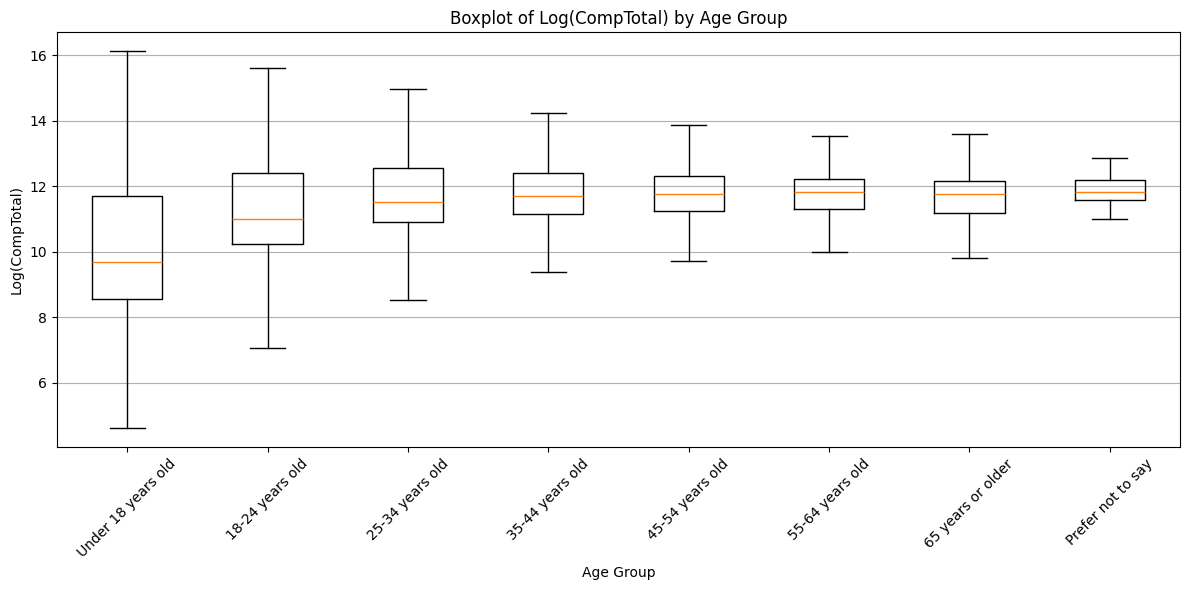

In [76]:
# Convert CompTotal to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop missing values
boxplot_data = df[['CompTotal','Age']].dropna()

# Remove top 1% extreme outliers
q99 = boxplot_data["CompTotal"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["CompTotal"] < q99]

# Log transformation
boxplot_data["LogCompTotal"] = np.log1p(boxplot_data["CompTotal"])

# Sort age groups for consistent plotting
age_order = [
            'Under 18 years old',
            '18-24 years old',
            '25-34 years old',
            '35-44 years old',
            '45-54 years old',
            '55-64 years old',
            '65 years or older',
            'Prefer not to say'
]

# Prepare data for each age group
grouped_data = [boxplot_data[boxplot_data["Age"] == age]["LogCompTotal"] for age in age_order]

# Plot all at once
plt.figure(figsize=(12,6))
plt.boxplot(grouped_data, tick_labels=age_order, showfliers=False)
plt.xlabel('Age Group')
plt.ylabel('Log(CompTotal)')
plt.title('Boxplot of Log(CompTotal) by Age Group')
plt.xticks(rotation=45)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [27]:
# your code goes here
df['JobSatPoints_6'].describe

count    29450.000000
mean        24.343232
std         27.089360
min          0.000000
25%          0.000000
50%         20.000000
75%         30.000000
max        100.000000
Name: JobSatPoints_6, dtype: float64

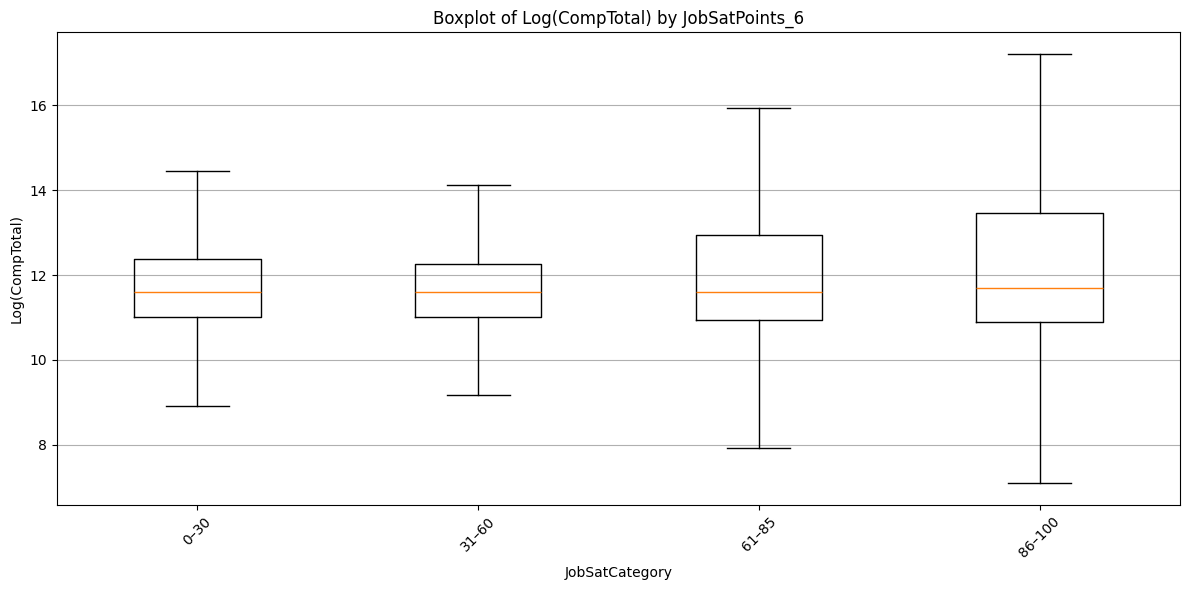

In [77]:
# Convert CompTotal to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop missing values
boxplot_data = df[['CompTotal','JobSatPoints_6']].dropna()

# Remove top 1% extreme outliers
q99 = boxplot_data["CompTotal"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["CompTotal"] < q99]

# Log transformation
boxplot_data["LogCompTotal"] = np.log1p(boxplot_data["CompTotal"])

# Turn JobSat to categorical groups
bins = [0, 30, 60, 85, 100]
labels = ['0–30', '31–60', '61–85', '86–100']
boxplot_data['JobSatCategory'] = pd.cut(boxplot_data['JobSatPoints_6'], bins=bins, labels=labels, include_lowest=True)

# Prepare data for each age group
grouped_data = [boxplot_data[boxplot_data["JobSatCategory"] == jobsat]["LogCompTotal"] for jobsat in labels]

# Plot all at once
plt.figure(figsize=(12,6))
plt.boxplot(grouped_data, tick_labels=labels, showfliers=False)
plt.xlabel('JobSatCategory')
plt.ylabel('Log(CompTotal)')
plt.title('Boxplot of Log(CompTotal) by JobSatPoints_6')
plt.xticks(rotation=45)
plt.grid (axis = 'y')
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


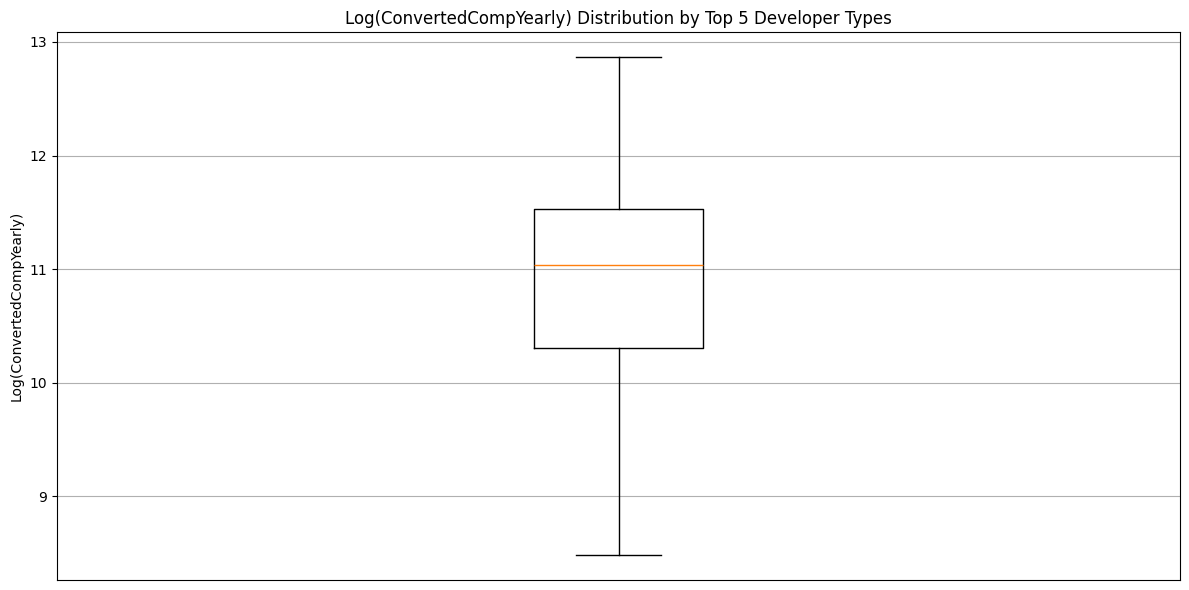

In [60]:
# your code goes here
# Convert ConvertedCompYearly to numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Drop missing values
boxplot_data = df[['ConvertedCompYearly','DevType']].dropna()

# Remove top 1% extreme outliers
q99 = boxplot_data["ConvertedCompYearly"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["ConvertedCompYearly"] < q99]

# Log transformation
boxplot_data["LogConvertedCompYearly"] = np.log1p(boxplot_data["ConvertedCompYearly"])

#Pick out top 5
top5 = df['DevType'].value_counts().nlargest(5)
top5_labels = top5.index.tolist()

#Filter only those top 5 DevTypes
boxplot_data = boxplot_data[boxplot_data['DevType'].isin(top5_labels)]

# Plot
plt.figure(figsize=(12,6))
plt.boxplot(boxplot_data['LogConvertedCompYearly'], showfliers=False)
# To draw a boxplot for each group
# plt.boxplot(
#     [boxplot_data[boxplot_data['DevType'] == dev]['LogConvertedCompYearly'] for dev in top5_labels],
#     labels=top5_labels,
#     showfliers=False
# )
#plt.xlabel('DevType')
#plt.xticks(rotation=45)
plt.xticks(ticks = [])
plt.ylabel('Log(ConvertedCompYearly)')
plt.title('Log(ConvertedCompYearly) Distribution by Top 5 Developer Types')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


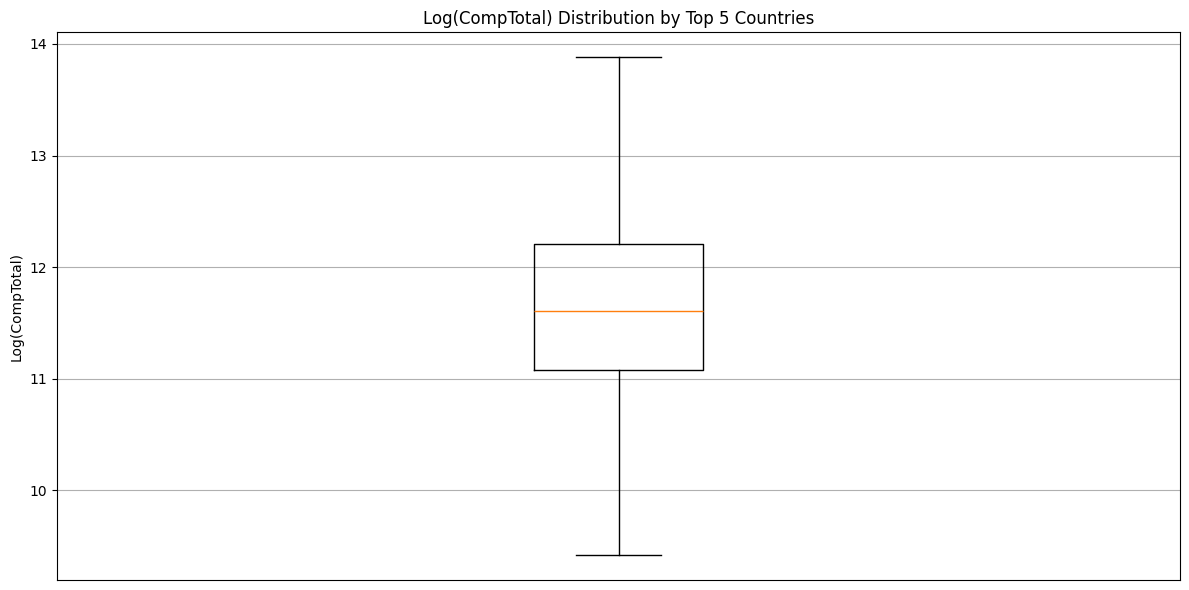

In [61]:
# your code goes here
# your code goes here
# Convert CompTotal to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop missing values
boxplot_data = df[['CompTotal','Country']].dropna()

# Remove top 1% extreme outliers
q99 = boxplot_data["CompTotal"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["CompTotal"] < q99]

# Log transformation
boxplot_data["LogCompTotal"] = np.log1p(boxplot_data["CompTotal"])

#Pick out top 5
top5 = df['Country'].value_counts().nlargest(5)
top5_labels = top5.index.tolist()

#Filter only those top 5 DevTypes
boxplot_data = boxplot_data[boxplot_data['Country'].isin(top5_labels)]

# Plot
plt.figure(figsize=(12,6))
plt.boxplot(boxplot_data['LogCompTotal'], showfliers=False)
# To draw a boxplot for each group
# plt.boxplot(
#     [boxplot_data[boxplot_data['Country'] == dev]['LogCompTotal'] for dev in top5_labels],
#     labels=top5_labels,
#     showfliers=False
# )
#plt.xlabel('Country')
#plt.xticks(rotation=45)
plt.xticks(ticks = [])
plt.ylabel('Log(CompTotal)')
plt.title('Log(CompTotal) Distribution by Top 5 Countries')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


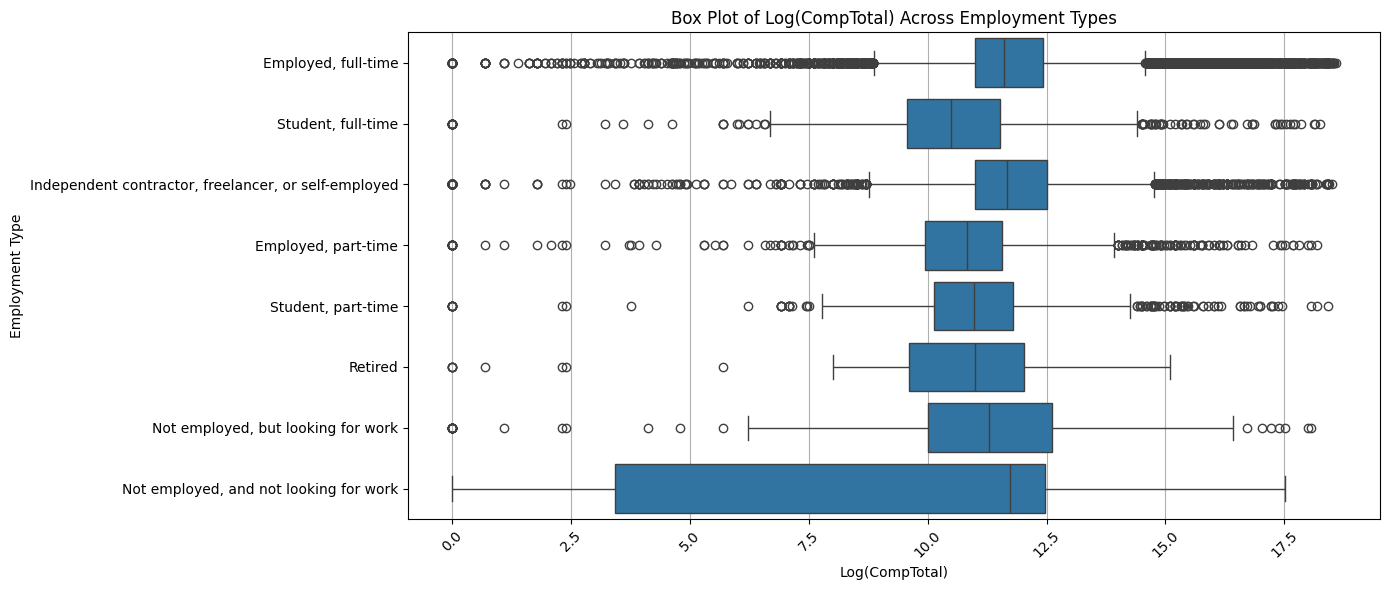

In [83]:
# Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Drop missing
df_filtered = df[['CompTotal', 'Employment']].dropna()

# Remove extreme outliers
q99 = df_filtered['CompTotal'].quantile(0.99)
df_filtered = df_filtered[df_filtered['CompTotal'] < q99]

# Log-transform
df_filtered['LogCompTotal'] = np.log1p(df_filtered['CompTotal'])

# Split and explode the Employment types
df_filtered['Employment'] = df_filtered['Employment'].str.split(';')
df_exploded = df_filtered.explode('Employment')

#Strip whitespace
df_exploded['Employment'] = df_exploded['Employment'].str.strip()

# Optional: Only keep top employment types
# top_employment = df_exploded['Employment'].value_counts().nlargest(5).index
# df_exploded = df_exploded[df_exploded['Employment'].isin(top_employment)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_exploded, y='Employment', x='LogCompTotal', showfliers=True)
plt.xticks(rotation=45)
plt.ylabel('Employment Type')
plt.xlabel('Log(CompTotal)')
plt.title('Box Plot of Log(CompTotal) Across Employment Types')
plt.tight_layout()
plt.grid(axis='x')
plt.show()

In [ ]:
#plt use vert = False to draw horizontal boxplot
#plt needs to set labels explicitly and pass a list of grouped data to plot multiple boxplot in the same figure

# employment_labels = df_exploded['Employment'].unique()
# # Group data: list of Series (one per Employment type)
# grouped_data = [
#     df_exploded[df_exploded['Employment'] == emp]['LogCompTotal'].dropna()
#     for emp in employment_labels
# ]

# plt.figure(figsize=(14, len(employment_labels) * 0.4))  # Adjust height based on number of labels
# plt.boxplot(grouped_data, labels=employment_labels, vert=False, showfliers=True)

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [85]:
df['YearsCodePro'].value_counts(dropna = False)

YearsCodePro
None                  13827
2                      4168
3                      4093
5                      3526
10                     3251
4                      3215
Less than 1 year       2856
6                      2843
1                      2639
8                      2549
7                      2517
12                     1777
15                     1635
20                     1549
9                      1493
11                     1312
13                     1127
14                     1082
25                      998
16                      946
18                      867
17                      814
30                      689
24                      632
19                      516
22                      492
23                      448
26                      426
27                      380
21                      380
28                      342
35                      285
29                      196
40                      194
32                      194
34     

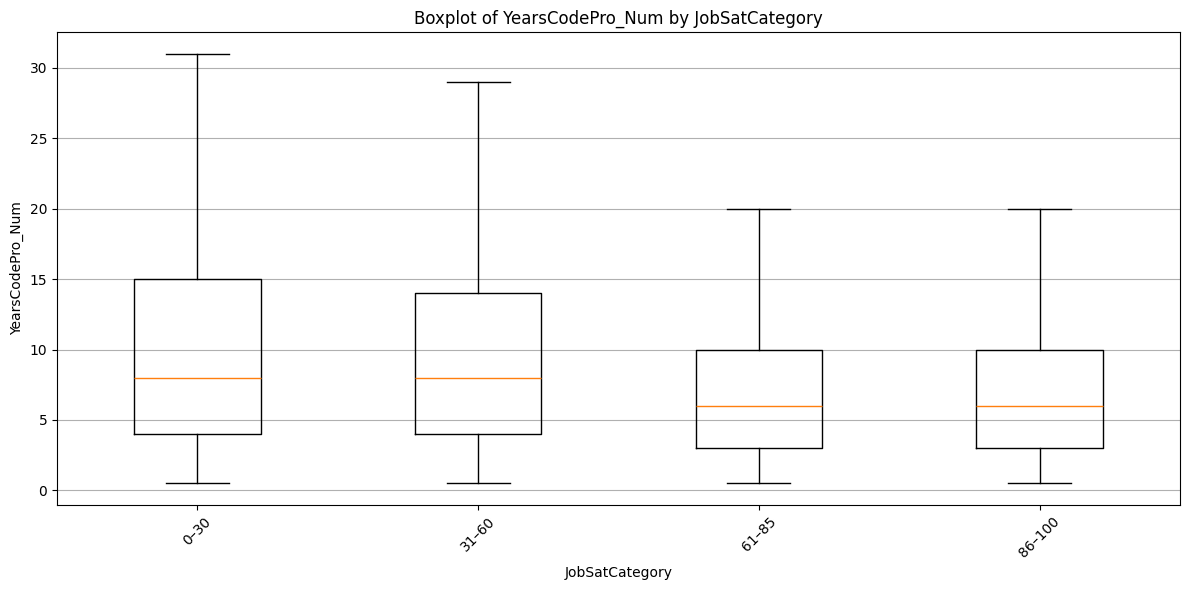

In [92]:
# your code goes here
#Convert YearsCodePro to number by mapping and cast type float
def convert_experience(val):
    if val == 'Less than 1 year':
        return 0.5
    elif val == 'More than 50 years':
        return 51
    elif pd.isna(val):
        return np.nan
    else:
        try:
            return float(val)
        except:
            return np.nan

df['YearsCodePro_Num'] = df['YearsCodePro'].apply(convert_experience)

# Drop missing values
boxplot_data = df[['YearsCodePro_Num','JobSatPoints_6']].dropna()

# Remove top 1% extreme outliers
q99 = boxplot_data["YearsCodePro_Num"].quantile(0.99)
boxplot_data = boxplot_data[boxplot_data["YearsCodePro_Num"] < q99]

# Log transformation
boxplot_data["LogYearsCodePro_Num"] = np.log1p(boxplot_data["YearsCodePro_Num"])

# Turn JobSat to categorical groups
bins = [0, 30, 60, 85, 100]
labels = ['0–30', '31–60', '61–85', '86–100']
boxplot_data['JobSatCategory'] = pd.cut(boxplot_data['JobSatPoints_6'], bins=bins, labels=labels, include_lowest=True)

# Prepare data for each age group
grouped_data = [boxplot_data[boxplot_data["JobSatCategory"] == jobsat]["YearsCodePro_Num"] for jobsat in labels]

# Plot all at once
plt.figure(figsize=(12,6))
plt.boxplot(grouped_data, tick_labels=labels, showfliers=True)
plt.xlabel('JobSatCategory')
plt.ylabel('YearsCodePro_Num')
plt.title('Boxplot of YearsCodePro_Num by JobSatCategory')
plt.xticks(rotation=45)
plt.grid (axis = 'y')
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [93]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
